In [1]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 12
       }

plt.rcParams['axes.grid'] = True

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=12) 
matplotlib.rc('ytick', labelsize=12) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
    
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.05 ):
            control_[:,:,i_time] = maxI_
    return control_

In [3]:
def set_init(init_v_):
    init_vars = aln.init_vars
    for i in range(len(init_vars)):
        if aln.params[init_vars[i]].size == 1:
            aln.params[init_vars[i]][0] = init_v_[i]
        else:
            aln.params[init_vars[i]][0,-1] = init_v_[i]
            
def setparams():
    
    aln.params.mue_ext_mean = 0.
    aln.params.mui_ext_mean = 0.
    
    aln.params.sigmae_ext = 0.1
    aln.params.sigmai_ext = 0.1
    
    aln.params.ext_exc_current = 0.
    aln.params.ext_inh_current = 0.
    
    """
    aln.params.Jee_max = 1e-26
    aln.params.cee = 0.
    #aln.params.Jei_max = 1.
    #aln.params.cei = 0.5
    aln.params.Jie_max = 1e-26
    aln.params.cie = 0.
    aln.params.Jii_max = 1e-26
    aln.params.cii = 0.

    # Coupling strengths used in Cakan2020
    params.Jee_max = 2.43  # mV/ms
    params.Jie_max = 2.60  # mV/ms
    params.Jei_max = -3.3  # mV/ms [0-(-10)]
    params.Jii_max = -1.64  # mV/ms
    """
    
    # NO ADAPTATION
    aln.params.IA_init = np.array([0.])
    aln.params.a = 0.
    aln.params.b = 0.
    
    aln.params.di = 0.0
    aln.params.de = 0.0
    aln.params.signalV = 0.


In [4]:
rates_exc_init = np.array( [[15. ]] )
rates_inh_init = np.array( [[15. ]] )
mufe_init = np.array( [[1. ]] )  # mV/ms
mufi_init = np.array( [[1. ]] )  # mV/ms
IA_init = np.array( [[0. ]] )  # pA
seem_init = np.array( [[0.0 * 0.5 ]] )
seim_init = np.array( [[0.0 * 0.5 ]] )   
seev_init = np.array( [[0.00 * 0.5 ]] )
seiv_init = np.array( [[0.00 * 0.5 ]] )
siim_init = np.array( [[0.0 * 0.5 ]] )
siem_init = np.array( [[0.0 * 0.5 ]] )
siiv_init = np.array( [[0.00 * 0.5 ]] )
siev_init = np.array( [[0.00 * 0.5 ]] )
mue_ou = np.array( [[0. ]] )
mui_ou = np.array( [[0. ]] )

initvars = np.array( [
rates_exc_init,
rates_inh_init,
mufe_init,
mufi_init,
IA_init,
seem_init ,
seim_init,
seev_init,
seiv_init,
siim_init,
siem_init,
siiv_init,
siev_init,
mue_ou,
mui_ou
    ])

max delay =  0


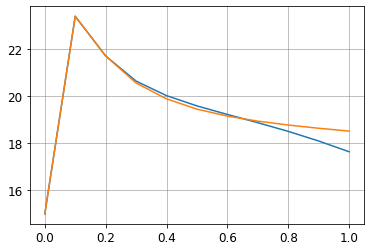

In [17]:
aln = ALNModel()
setparams()
set_init(initvars)
aln.params['duration'] = 1.

control0 = aln.getZeroControl()
#control0 = step_control(maxI_ = 1.)

maxDelay = aln.getMaxDelay()
print("max delay = ", maxDelay)

aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

In [7]:
dur_pre = 0.
dur_post = 0.

max_it = 1
tol = 1e-16

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])


In [8]:
def plot_fig(i):
    lines = 8
    fig, axes = plt.subplots(lines,2, figsize=(18, 12))
    axes[0,i].plot(aln.t, control1[0,0,:], label="control exc")
    axes[0,i+1].plot(aln.t, control1[0,1,:], label="control inh")
    axes[1,i].plot(aln.t, aln.state["rates_exc"][0,:], label="rates exc")
    axes[1,i+1].plot(aln.t, aln.state["rates_inh"][0,:], label="rates inh")
    axes[2,i].plot(aln.t, aln.state["mufe"][0,:], label="mufe")
    axes[2,i+1].plot(aln.t, aln.state["mufi"][0,:], label="mufi")
    #axes[3,i].plot(aln.t, aln.state["IA"][0,:], label="IA")

    axes[4,i].plot(aln.t, aln.state["seem"][0,:], label="seem")
    axes[3,i].plot(aln.t, aln.state["seim"][0,:], label="seim")
    axes[4,i+1].plot(aln.t, aln.state["siem"][0,:], label="siem")
    axes[3,i+1].plot(aln.t, aln.state["siim"][0,:], label="siim")

    axes[5,i].plot(aln.t, aln.state["seev"][0,:], label="seev")
    axes[5,i+1].plot(aln.t, aln.state["seiv"][0,:], label="seiv")
    axes[6,i].plot(aln.t, aln.state["siev"][0,:], label="siev")
    axes[6,i+1].plot(aln.t, aln.state["siiv"][0,:], label="siiv")

    #axes[6,i].plot(aln.t, aln.state["mue_ou"][0,:], label="mue_ou")
    #axes[6,i+1].plot(aln.t, aln.state["mui_ou"][0,:], label="mui_ou")

    axes[7,i].plot(aln.t, aln.state["sigmae_f"][0,:], label="sigma_e")
    axes[7,i+1].plot(aln.t, aln.state["sigmai_f"][0,:], label="sigma_i")
    #axes[8,i].plot(aln.t, aln.state["Vmean_exc"][0,:], label="V_mean")
    #axes[9,i].plot(aln.t, aln.state["tau_exc"][0,:], label="tau_exc")
    #axes[9,i+1].plot(aln.t, aln.state["tau_inh"][0,:], label="tau_inh")

    for k in range(lines):
        for j in range(2):
            #if ((k,j) != (3,1) and (k,j) != (8,1)):
            axes[k,j].legend()

    plt.tight_layout()
    
def plot_phi(phi):
    lines = 9
    time = np.arange(0, dur+aln.params.dt, aln.params.dt)
    
    fig, axes = plt.subplots(lines,2, figsize=(18, 26))
    
    axes[0,0].plot(time, phi[0,0,:], label="phi0 - adjoint exc rate")
    axes[0,1].plot(time, phi[0,1,:], label="phi1 - adjoint inh rate")
    
    axes[1,0].plot(time, phi[0,2,:], label="phi2 - adjoint mufe")
    axes[1,1].plot(time, phi[0,3,:], label="phi3 - adjoint mufi")
    
    axes[2,0].plot(time, phi[0,6,:], label="phi6 - adjoint seim")
    axes[2,1].plot(time, phi[0,8,:], label="phi8 - adjoint siim")
    
    axes[3,0].plot(time, phi[0,4,:], label="phi4 - adjoint IA")
    axes[3,1].plot(time, phi[0,17,:], label="phi17 - adjoint V")
    
    axes[4,0].plot(time, phi[0,5,:], label="phi6 - adjoint seem")
    axes[4,1].plot(time, phi[0,7,:], label="phi8 - adjoint siem")
    
    axes[5,0].plot(time, phi[0,9,:], label="phi9 - adjoint seev")
    axes[5,0].plot(time, phi[0,10,:], label="phi10 - adjoint seiv")
    axes[5,1].plot(time, phi[0,11,:], label="phi11 - adjoint siev")
    axes[5,1].plot(time, phi[0,12,:], label="phi12 - adjoint siiv")
    
    axes[6,0].plot(time, phi[0,13,:], label="phi13 - adjoint mue ou")
    axes[6,1].plot(time, phi[0,14,:], label="phi14 - adjoint mui ou")
    
    axes[7,0].plot(time, phi[0,15,:], label="phi15 - adjoint sigma e")
    axes[7,1].plot(time, phi[0,16,:], label="phi16 - adjoint sigma i")
    
    axes[8,0].plot(time, phi[0,18,:], label="phi18 - adjoint tau e")
    axes[8,1].plot(time, phi[0,19,:], label="phi19 - adjoint tau i")

    for k in range(lines):
        for j in range(2):
            axes[k,j].legend()

    plt.tight_layout()

[15.         23.39774207 21.70888326 20.6321207  20.01424687 19.58428427
 19.1826479  18.76907918 18.3793965  17.93884    17.4465567 ]
[15.         23.39774207 23.39774207 22.08922279 19.69414868 19.25715499
 20.31073881 20.02425615 19.79953574 19.60618983 19.42254843]


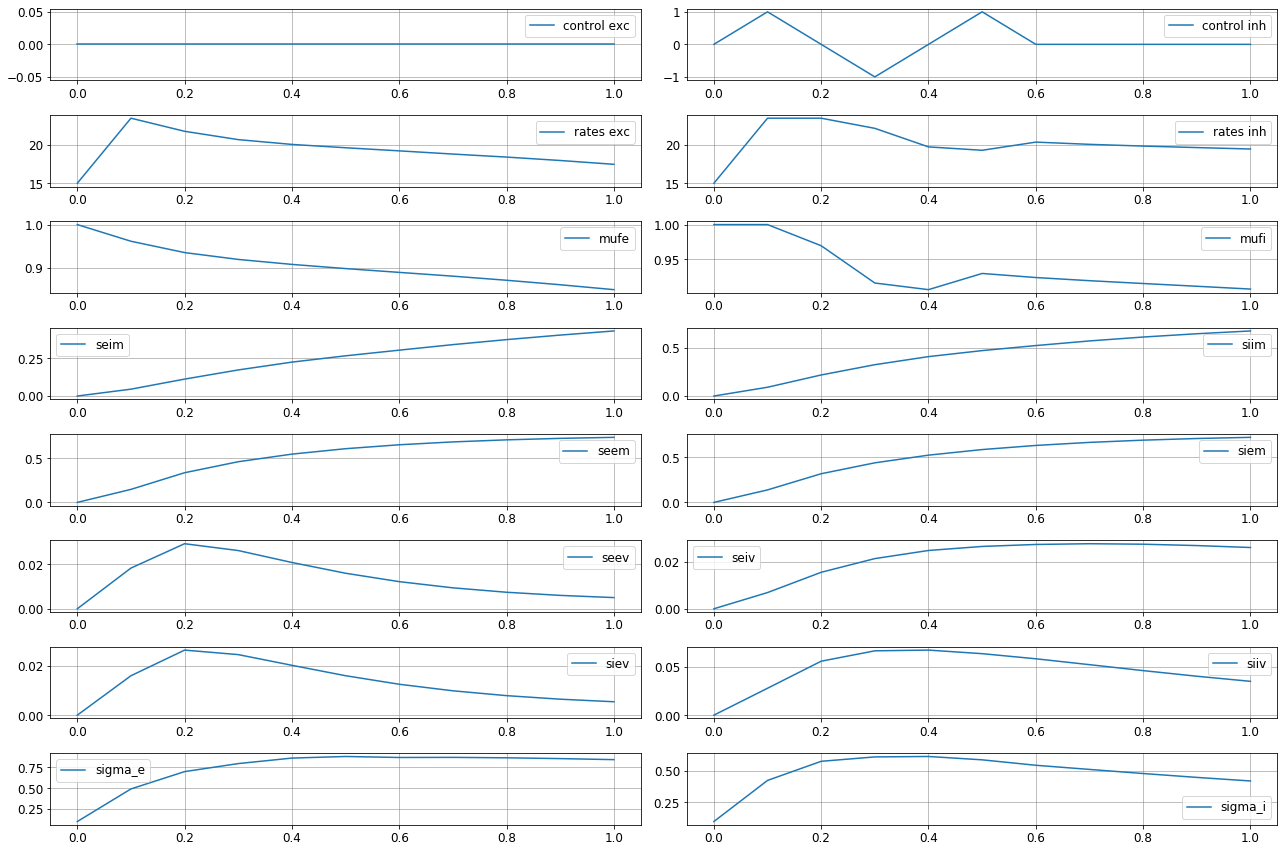

In [18]:
#setparams()

dur = 1.
aln.params.duration = dur
aln.params.di = 0.0

target = aln.getZeroTarget()
control1 = aln.getZeroControl()

set_init(initvars)

#control1[0,0,1] += 100.
#control1[0,0,:] += np.sin(6.*np.arange(0,dur+aln.params.dt,aln.params.dt))

control1 = aln.getZeroControl()
control1[0,1,3] -= 1.
control1[0,1,1] += 1.
control1[0,1,5] += 1.
#control1[0,1,:] += np.cos(6.*np.arange(0,dur+aln.params.dt,aln.params.dt))

aln.run(control=control1)

target[:,0,:] = aln.state["rates_exc"][0,:]
target[:,1,:] = aln.state["rates_inh"][0,:]

plot_fig(0)
rates1 = aln.state["rates_exc"][0,:]
print(aln.state["rates_exc"][0,:])
print(aln.state["rates_inh"][0,:])

[15.         23.39774207 21.72216677 20.64706456 20.04670091 19.80126288
 19.58635718 19.34829808 19.01111348 18.59433938 18.15618897]
[15.         23.39774207 23.39774207 22.09930849 19.79599583 19.54261036
 20.75651184 20.56054357 20.38014285 20.22261212 20.07715349]


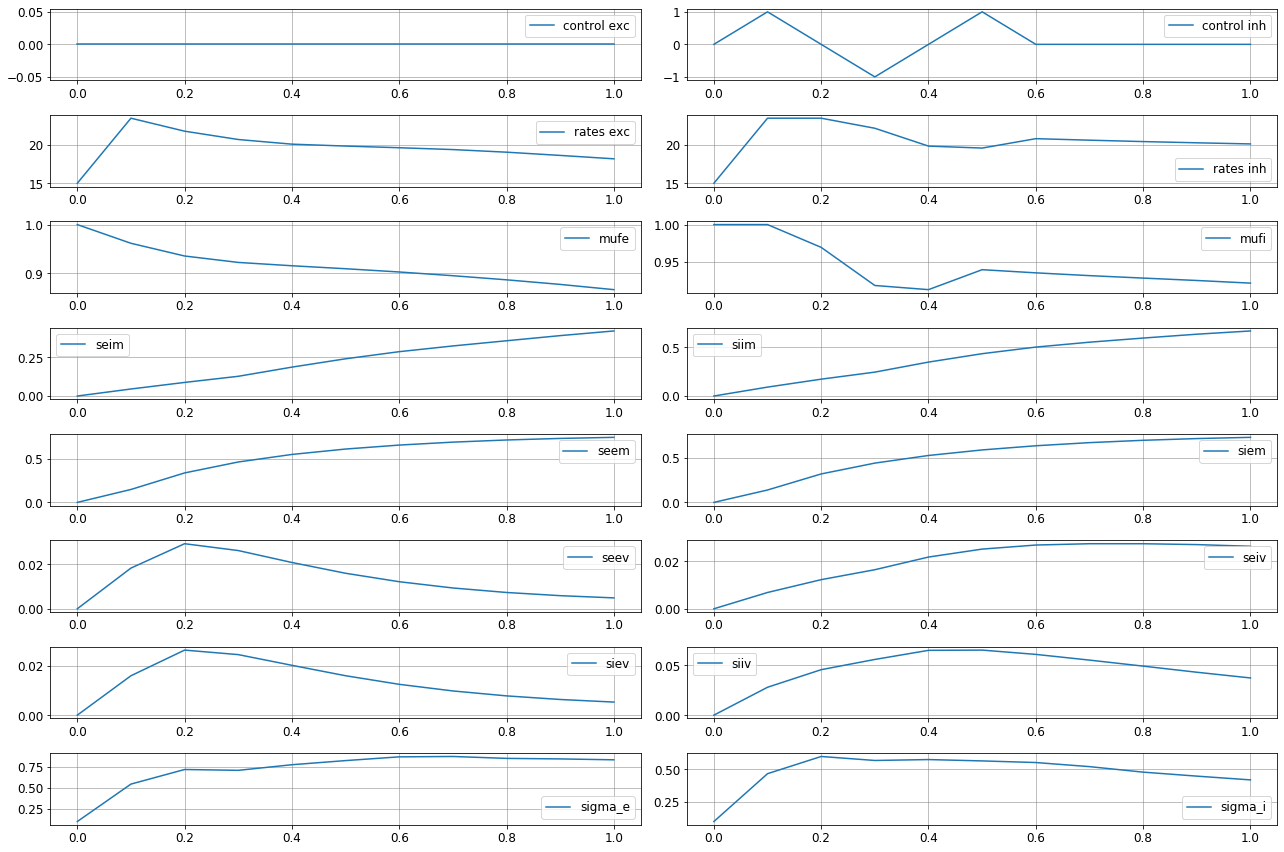

In [19]:
aln.params.di = 0.2
aln.run(control=control1)

rates2 = aln.state["rates_exc"][0,:]
print(aln.state["rates_exc"][0,:])
print(aln.state["rates_inh"][0,:])
plot_fig(0)
target[:,0,:] = aln.state["rates_exc"][0,:]
target[:,1,:] = aln.state["rates_inh"][0,:]

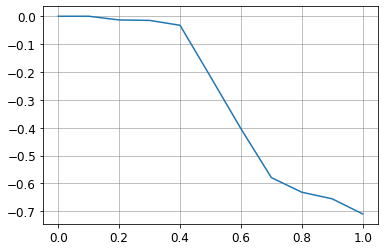

In [14]:
plt.plot(aln.t, rates1-rates2)

In [24]:
max_cntrl = 50. * 5.
start_step = 100.
cost_params = [1.0, 0.0, 0.0]

#aln.params.di = 0.0

cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = aln.getZeroControl()
#control2 = control1
#control2[0,1,:] += 0.1
#control2[0,1,7] += 0.1

max_it = 100
set_init(initvars)

A1_bestControl, A1_bestState, A1_cost, runtime = aln.A1(A1_bestControl, target, c_scheme, u_mat,
        u_scheme, max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        variables_ = [0])

err = False
for c in range(len(A1_cost)-1):
    if A1_cost[c] < A1_cost[c+1]:
        print("ERROR in index ", c)
        err = True
        break
if not err:
    print("cost decreases throughout computation")

ERROR:root:Not possible to set up initial conditions without sufficient simulation time before control


set cost params
True 2
RUN  0 , total integrated cost =  2.886522847940869e-11
too small start step, increase to  100000.0
RUN  1 , total integrated cost =  2.8437525485068282e-11
RUN  2 , total integrated cost =  2.7844269490211516e-11
RUN  3 , total integrated cost =  2.780413288551551e-11
RUN  4 , total integrated cost =  2.7608864959872008e-11
RUN  5 , total integrated cost =  2.750011309047788e-11
too small start step, increase to  100000.0
RUN  6 , total integrated cost =  2.7347392515930176e-11
RUN  7 , total integrated cost =  2.7086703913029937e-11
RUN  8 , total integrated cost =  2.7048896131173712e-11
too small start step, increase to  100000.0
RUN  9 , total integrated cost =  2.6696367383099607e-11
RUN  10 , total integrated cost =  2.643674366709963e-11
RUN  11 , total integrated cost =  2.6372049307470464e-11
RUN  12 , total integrated cost =  2.6224167597351732e-11
RUN  13 , total integrated cost =  2.6177344893089096e-11
too small start step, increase to  100000.0
RUN

RUN  28 , total integrated cost =  4.397196643173981e-12
too small start step, increase to  100000.0
RUN  29 , total integrated cost =  4.358856483107424e-12
RUN  30 , total integrated cost =  4.3011011844354786e-12
RUN  31 , total integrated cost =  4.295170287990445e-12
too small start step, increase to  100000.0
RUN  32 , total integrated cost =  4.252473935227846e-12
RUN  33 , total integrated cost =  4.2236152788749e-12
RUN  34 , total integrated cost =  4.209695914878976e-12
RUN  35 , total integrated cost =  4.181778271165298e-12
RUN  36 , total integrated cost =  4.175657564124484e-12
too small start step, increase to  100000.0
RUN  37 , total integrated cost =  3.863111325059613e-12
RUN  38 , total integrated cost =  3.6160871802210442e-12
too small start step, increase to  100000.0
RUN  39 , total integrated cost =  3.5707248539193586e-12
RUN  40 , total integrated cost =  3.5065028748183806e-12
RUN  41 , total integrated cost =  3.501154902755199e-12
RUN  42 , total integrat

RUN  53 , total integrated cost =  3.1980968748482036e-12
RUN  54 , total integrated cost =  3.1923258452233373e-12
RUN  55 , total integrated cost =  3.1751763087693287e-12
RUN  56 , total integrated cost =  3.1688499771634862e-12
too small start step, increase to  100000.0
RUN  57 , total integrated cost =  2.065498363388177e-12
RUN  58 , total integrated cost =  1.243001167630596e-12
RUN  59 , total integrated cost =  1.2355714879843684e-12
RUN  60 , total integrated cost =  1.2318714089021703e-12
too small start step, increase to  100000.0
RUN  61 , total integrated cost =  1.2225708760092854e-12
RUN  62 , total integrated cost =  1.209049234616228e-12
RUN  63 , total integrated cost =  1.2072956114217626e-12
RUN  64 , total integrated cost =  1.1991539999308392e-12
RUN  65 , total integrated cost =  1.1942856066624358e-12
too small start step, increase to  100000.0
RUN  66 , total integrated cost =  1.1878578654755118e-12
RUN  67 , total integrated cost =  1.1780304887816873e-12
R

RUN  80 , total integrated cost =  4.926645310059427e-13
too small start step, increase to  100000.0
RUN  81 , total integrated cost =  4.856615693472498e-13
RUN  82 , total integrated cost =  4.812538305737938e-13
RUN  83 , total integrated cost =  4.800122620518423e-13
RUN  84 , total integrated cost =  4.772533580328095e-13
RUN  85 , total integrated cost =  4.764423700398055e-13
too small start step, increase to  100000.0
RUN  86 , total integrated cost =  2.7868453893685733e-13
RUN  87 , total integrated cost =  1.5887405472304663e-13
RUN  88 , total integrated cost =  1.5816924989256469e-13
RUN  89 , total integrated cost =  1.5778511952361662e-13
too small start step, increase to  100000.0
RUN  90 , total integrated cost =  1.526452744595818e-13
RUN  91 , total integrated cost =  1.4828409143931417e-13
too small start step, increase to  100000.0
RUN  92 , total integrated cost =  1.4446997791416533e-13
RUN  93 , total integrated cost =  1.4035143498239028e-13
RUN  94 , total int

[15.         23.39774207 21.72216677 20.64706456 20.04670091 19.80126435
 19.58635757 19.34829822 19.01111347 18.59433915 18.15618895]
[ 0.00000000e+00  9.99912663e-01  4.23593129e-05 -9.99942835e-01
  7.39252724e-05  1.00008417e+00 -2.04385582e-06 -1.91467805e-03
 -2.18289206e-03  0.00000000e+00  0.00000000e+00]
[15.         23.39774207 21.72216677 20.64706456 20.04670091 19.80126288
 19.58635718 19.34829808 19.01111348 18.59433938 18.15618897]


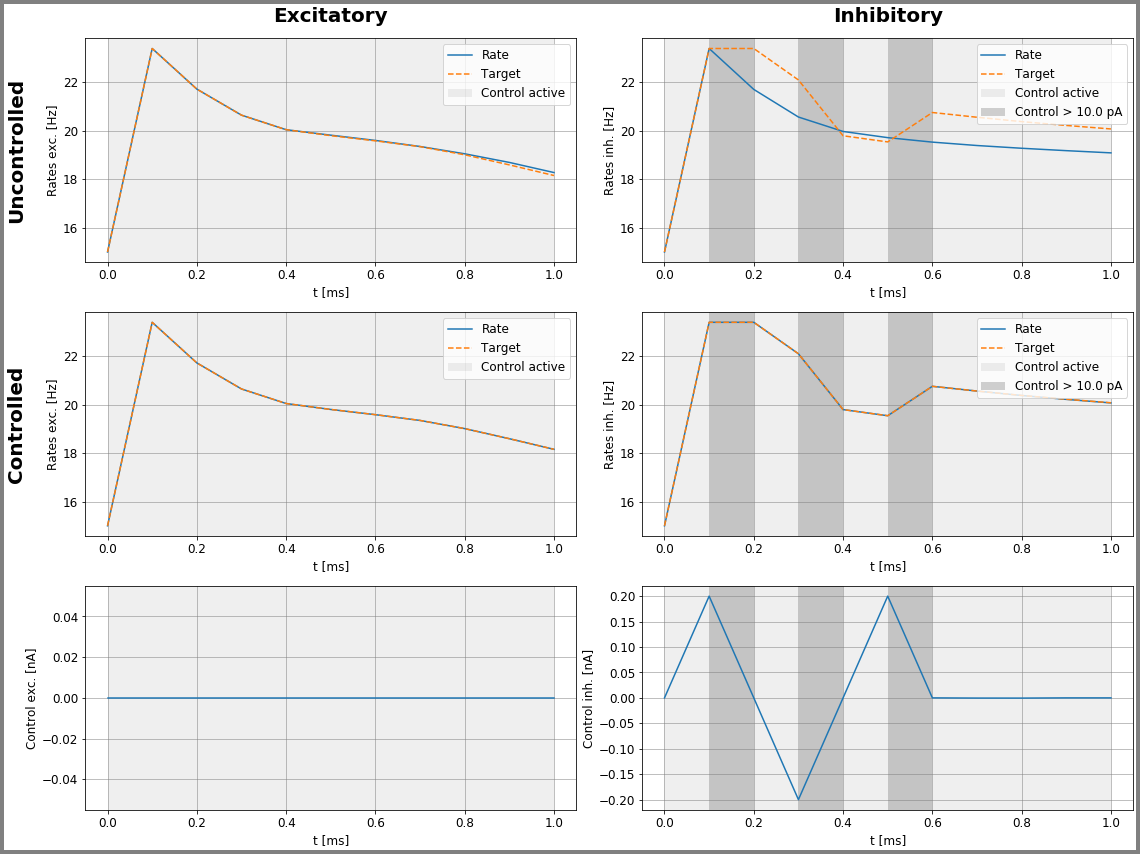

In [25]:
print(A1_bestState[0,0,:])
print(A1_bestControl[0,1,:])
print(target[0,0,:])
plotFunc.plot_control(aln, A1_bestControl, dur, dur_pre, dur_post, initvars, target,
                      path, filename_ = 'a1')

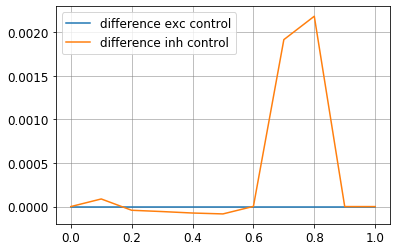

In [26]:
cDiff = control1 - A1_bestControl
plt.plot(aln.t, cDiff[0,0,:], label="difference exc control")
plt.plot(aln.t, cDiff[0,1,:], label="difference inh control")
plt.legend()
plt.show()

#plt.plot(aln.t, grad[0,1,:])
#plt.show()

### For excitatory control input only

max delay =  0


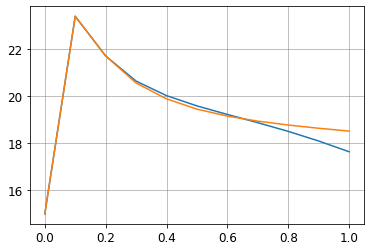

In [28]:
aln = ALNModel()
setparams()
set_init(initvars)
aln.params['duration'] = 1.

control0 = aln.getZeroControl()
#control0 = step_control(maxI_ = 1.)

maxDelay = aln.getMaxDelay()
print("max delay = ", maxDelay)

aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

[15.         23.39774207 23.39774207 22.15102421 19.82985197 19.44732656
 20.4870312  20.10711487 19.70197639 19.26744767 18.78400532]
[15.         23.39774207 21.70888326 20.55793917 19.88499869 19.4902409
 19.24872086 19.07303268 18.93242007 18.82955818 18.74353137]


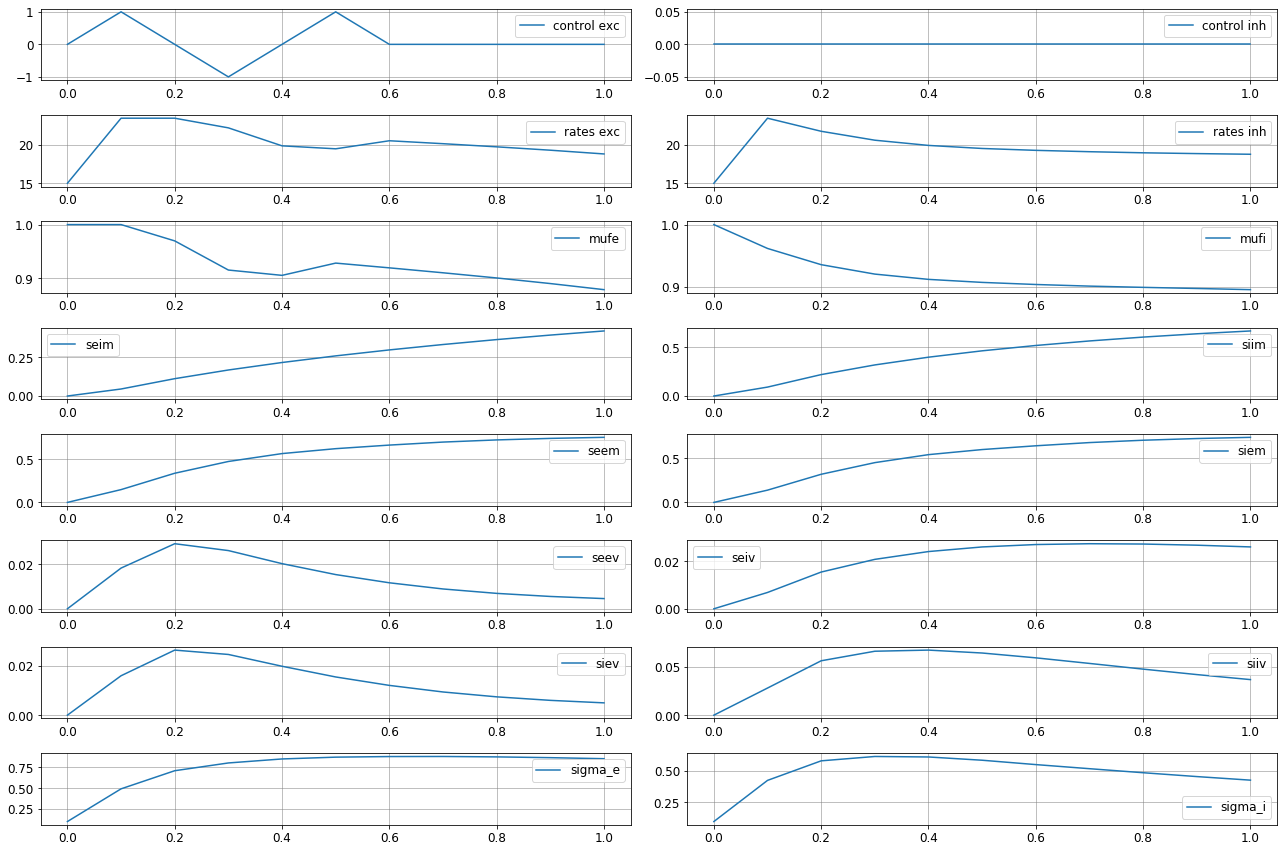

In [29]:
dur = 1.
aln.params.duration = dur
aln.params.de = 0.0
aln.params.di = 0.0

target = aln.getZeroTarget()
control1 = aln.getZeroControl()

set_init(initvars)

#control1[0,0,1] += 100.
#control1[0,0,:] += np.sin(6.*np.arange(0,dur+aln.params.dt,aln.params.dt))

control1 = aln.getZeroControl()
control1[0,0,3] -= 1.
control1[0,0,1] += 1.
control1[0,0,5] += 1.
#control1[0,1,:] += np.cos(6.*np.arange(0,dur+aln.params.dt,aln.params.dt))

aln.run(control=control1)

target[:,0,:] = aln.state["rates_exc"][0,:]
target[:,1,:] = aln.state["rates_inh"][0,:]

plot_fig(0)
rates1 = aln.state["rates_inh"][0,:]
print(aln.state["rates_exc"][0,:])
print(aln.state["rates_inh"][0,:])

[15.         23.39774207 23.40211254 22.16096823 19.54692323 18.82048523
 19.63050498 19.18293761 18.77724601 18.35205804 17.88773539]
[15.         23.39774207 21.70888326 20.56803532 19.61810121 18.84882225
 18.37794006 18.10470315 17.94001852 17.80696513 17.70898854]


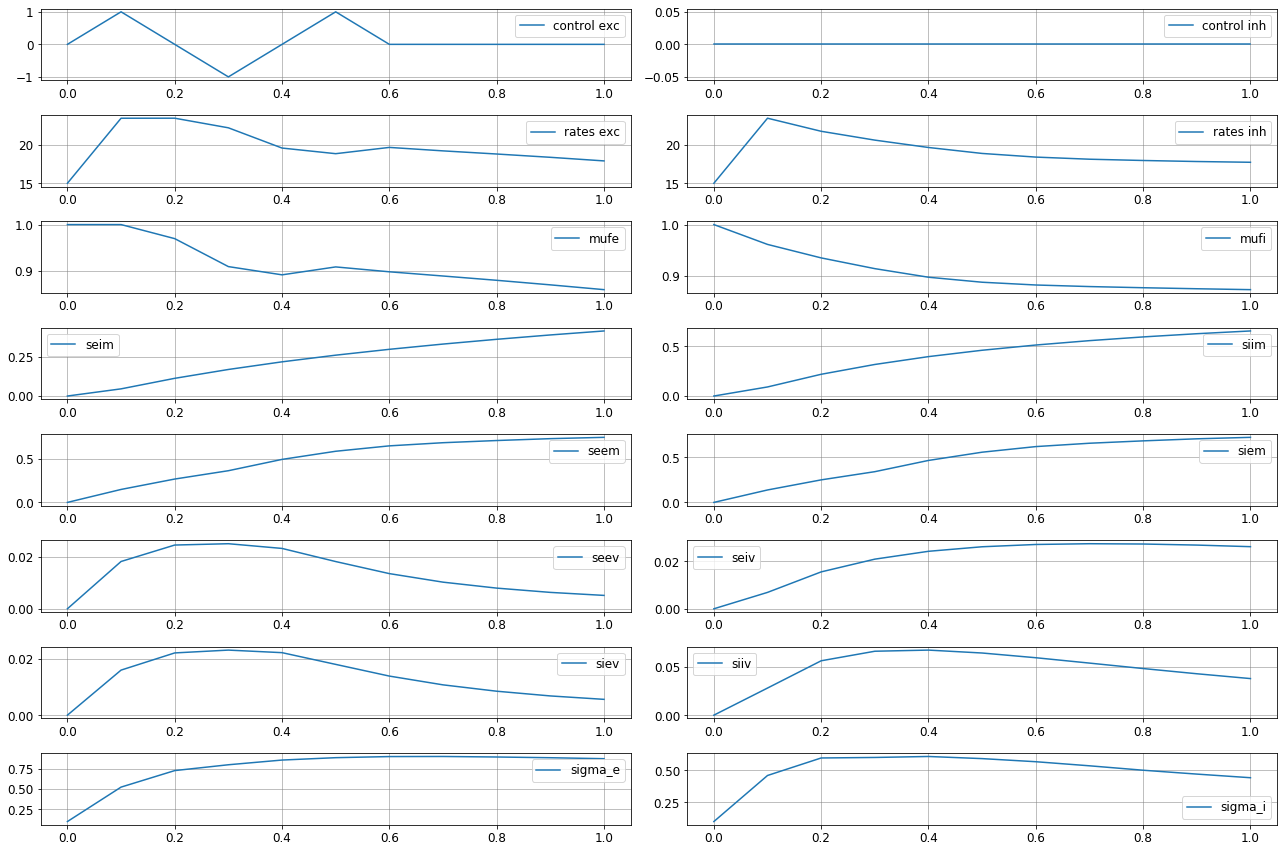

In [30]:
aln.params.de = 0.2
aln.run(control=control1)

rates2 = aln.state["rates_inh"][0,:]
print(aln.state["rates_exc"][0,:])
print(aln.state["rates_inh"][0,:])
plot_fig(0)
target[:,0,:] = aln.state["rates_exc"][0,:]
target[:,1,:] = aln.state["rates_inh"][0,:]

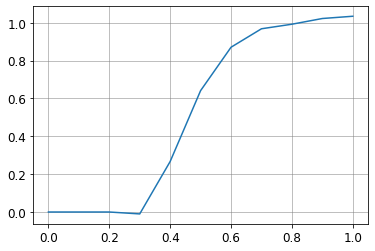

In [31]:
plt.plot(aln.t, rates1-rates2)

In [55]:
max_cntrl = 50. * 5.
start_step = 100.
cost_params = [1.0, 0.0, 0.0]

#aln.params.di = 0.0

cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = aln.getZeroControl()
#control2 = control1
#control2[0,1,:] += 0.1
#control2[0,1,7] += 0.1

max_it = 1000
set_init(initvars)

A1_bestControl, A1_bestState, A1_cost, runtime = aln.A1(A1_bestControl, target, c_scheme, u_mat,
        u_scheme, max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        variables_ = [1])

err = False
for c in range(len(A1_cost)-1):
    if A1_cost[c] < A1_cost[c+1]:
        print("ERROR in index ", c)
        err = True
        break
if not err:
    print("cost decreases throughout computation")

ERROR:root:Not possible to set up initial conditions without sufficient simulation time before control


set cost params
True 2
RUN  0 , total integrated cost =  4.242420568958249e-10
test control change smaller than tolerance, return zero step
RUN  1 , total integrated cost =  4.242420568958249e-10
Control only changes marginally.
Improved over  1  iterations by  0.0  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([4], dtype=int64)) 1.2474977759370836e-08
min value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([1], dtype=int64)) -2.794359063533967e-08
cost decreases throughout computation


[15.         23.39774207 23.39203575 22.19705571 19.42412977 18.99415049
 18.84603464 18.44309352 18.07275736 17.67947871 17.25156166]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[15.         23.39774207 23.40211254 22.16096823 19.54692323 18.82048523
 19.63050498 19.18293761 18.77724601 18.35205804 17.88773539]


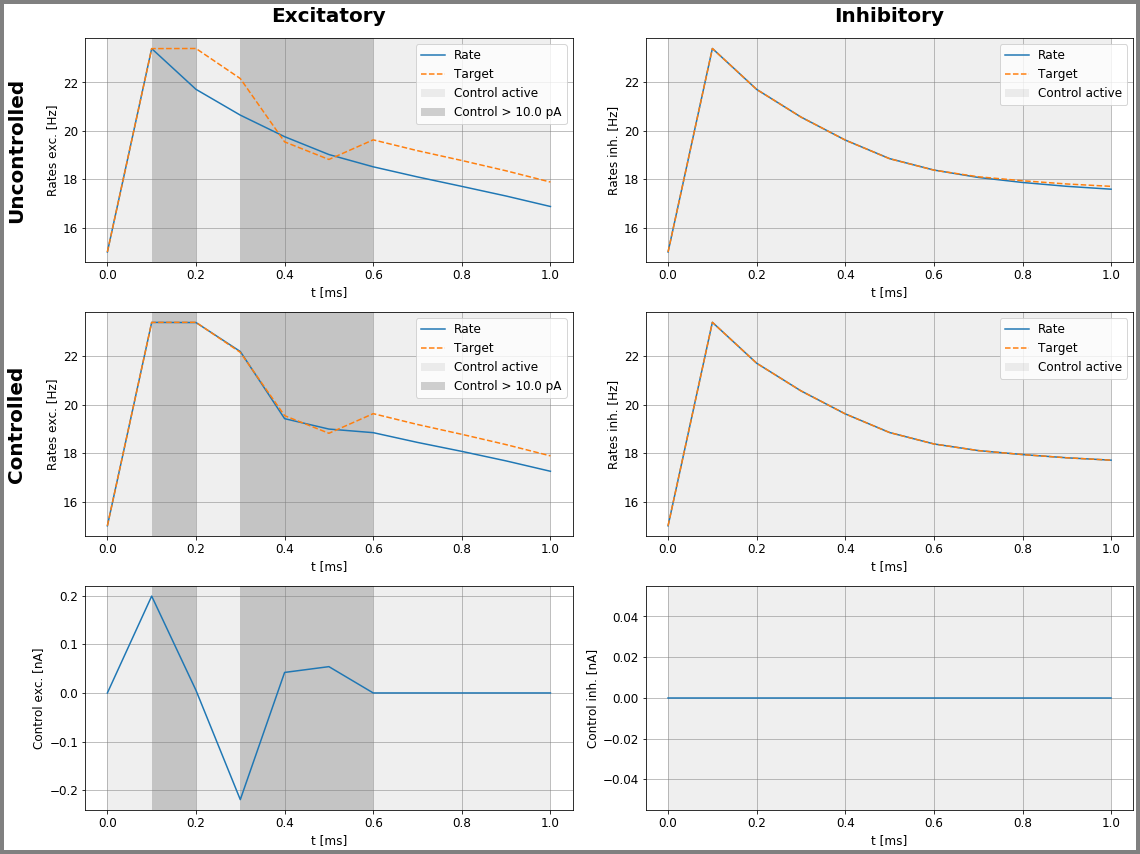

In [54]:
print(A1_bestState[0,0,:])
print(A1_bestControl[0,1,:])
print(target[0,0,:])
plotFunc.plot_control(aln, A1_bestControl, dur, dur_pre, dur_post, initvars, target,
                      path, filename_ = 'a1')

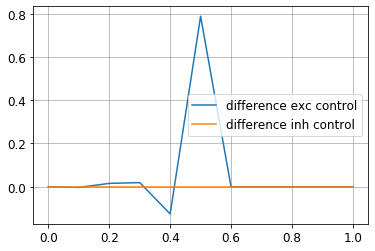

In [42]:
cDiff = control1 - A1_bestControl
plt.plot(aln.t, cDiff[0,0,:], label="difference exc control")
plt.plot(aln.t, cDiff[0,1,:], label="difference inh control")
plt.legend()
plt.show()

#plt.plot(aln.t, grad[0,1,:])
#plt.show()